# Approximate Hybrid Quantum State Preparation for a PPG Signal

## Imports

In [7]:
import sys
sys.path.append("../src")

In [8]:
import numpy as np
import pandas as pd
import os
import math
import matplotlib.pyplot as plt

from hybridqsp.transforms import dft, idft
from hybridqsp.transforms import haar_packet_transform, inverse_haar_packet_transform
from hybridqsp.quantum import build_inverse_qphwt_circuit
from hybridqsp.thresholding import top_k_threshold, magnitude_threshold
from hybridqsp.analysis import search_sparse_haar_representations
from hybridqsp.metrics import state_fidelity, trace_distance

## PPG Signal Loading

A sample PPG signal is loaded from the `ppg_dataset/` directory for hybrid quantum reconstruction experiments.

In [9]:
signal = np.load(
    "../ppg-dataset/ppg_sample.npy"
)

n = 10
N = 2**n

target_f = (
    signal[:N] /
    np.linalg.norm(signal[:N])
)

### Visualization of Signal

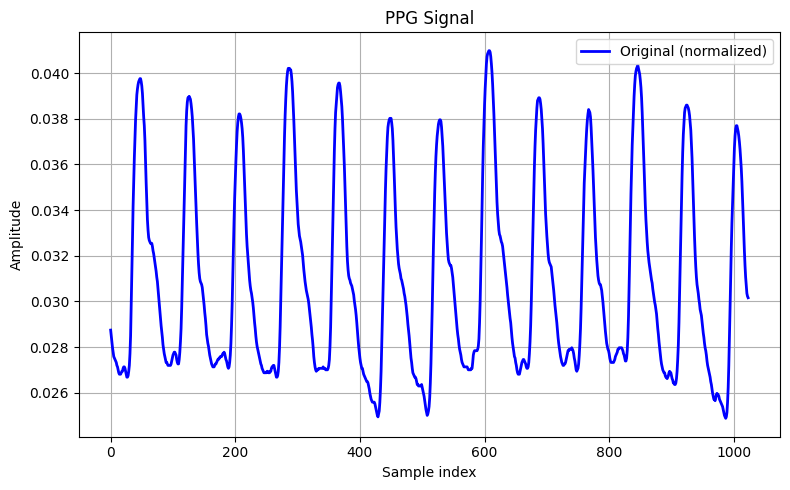

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(target_f, label="Original (normalized)", lw=2, color="blue")

plt.title(f"PPG Signal")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();
plt.show()

Perfect FFT reconstruction
L2 error = 1.6736261120298603e-16

Top-k reconstruction
k= 10 | nonzero= 10 | energy=0.996952 | L2=0.054205
k= 20 | nonzero= 20 | energy=0.998467 | L2=0.038671
k= 50 | nonzero= 50 | energy=0.999604 | L2=0.019690
k=100 | nonzero=100 | energy=0.999969 | L2=0.005495
k=200 | nonzero=200 | energy=0.999997 | L2=0.001601


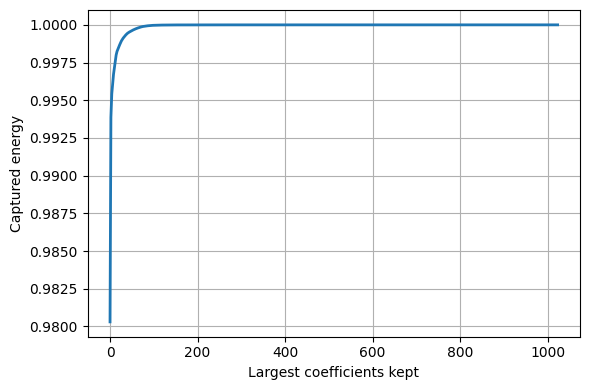

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load signal
# ============================================================

signal = np.load("../ppg-dataset/ppg_sample.npy")

n = 10
N = 2**n

x = signal[:N].astype(float)
x /= np.linalg.norm(x)

# ============================================================
# Reference FFT (NumPy)
# ============================================================

X = np.fft.fft(x)

# ============================================================
# Top-k threshold
# ============================================================

def topk(x, k):
    """
    Keep the k largest-magnitude coefficients.
    """

    y = np.zeros_like(x)

    idx = np.argpartition(np.abs(x), -k)[-k:]

    y[idx] = x[idx]

    return y

# ============================================================
# Diagnostics
# ============================================================

print("="*70)
print("Perfect FFT reconstruction")
print("="*70)

xr = np.fft.ifft(X)

print("L2 error =", np.linalg.norm(x - xr.real))

print()

print("="*70)
print("Top-k reconstruction")
print("="*70)

for k in [10,20,50,100,200]:

    Xk = topk(X, k)

    energy = (
        np.sum(np.abs(Xk)**2)
        /
        np.sum(np.abs(X)**2)
    )

    xr = np.fft.ifft(Xk)

    l2 = np.linalg.norm(x - xr.real)

    print(
        f"k={k:3d} | "
        f"nonzero={np.count_nonzero(Xk):3d} | "
        f"energy={energy:.6f} | "
        f"L2={l2:.6f}"
    )

# ============================================================
# Cumulative energy
# ============================================================

coeff = np.sort(np.abs(X))[::-1]

energy = np.cumsum(coeff**2)
energy /= energy[-1]

plt.figure(figsize=(6,4))

plt.plot(energy, lw=2)

plt.xlabel("Largest coefficients kept")
plt.ylabel("Captured energy")

plt.grid(True)

plt.tight_layout()
plt.show()

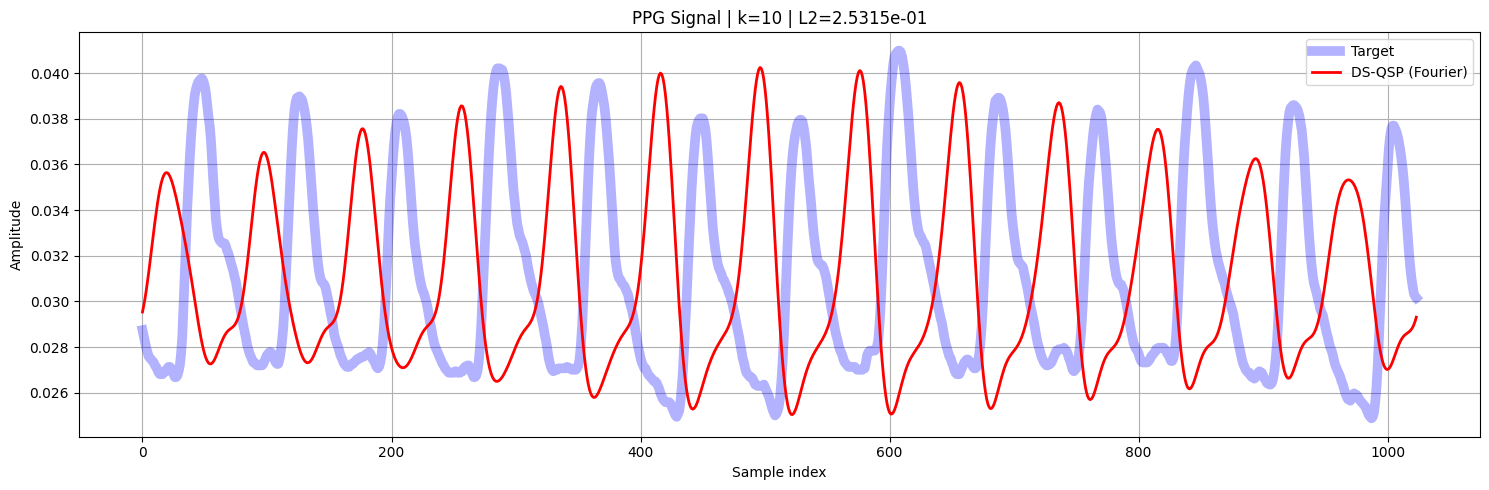

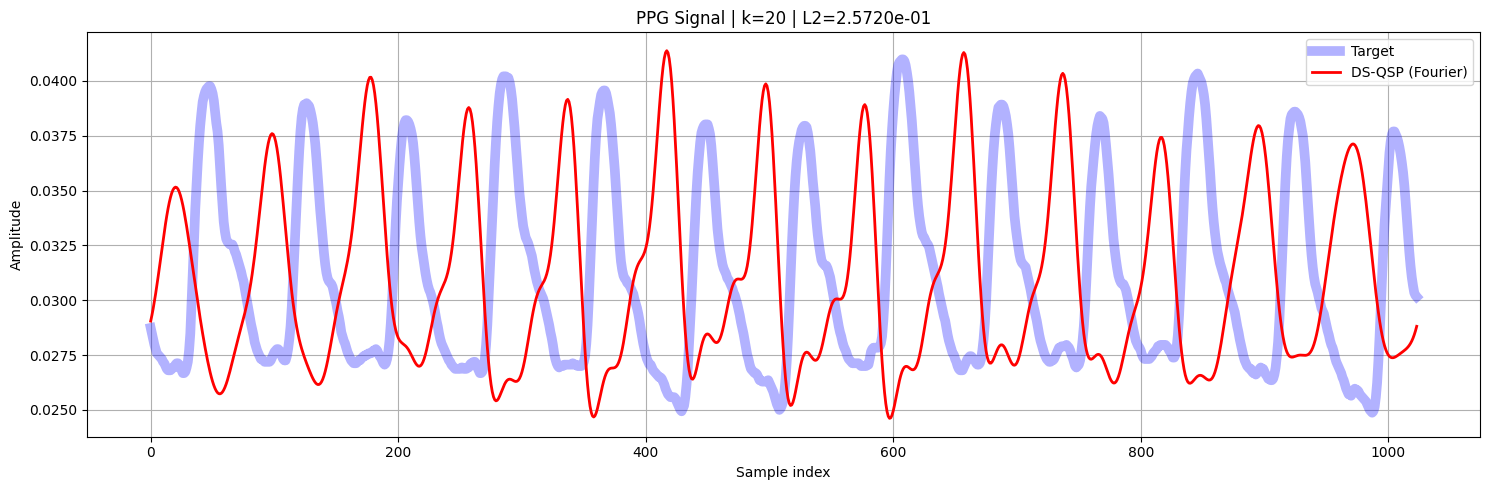

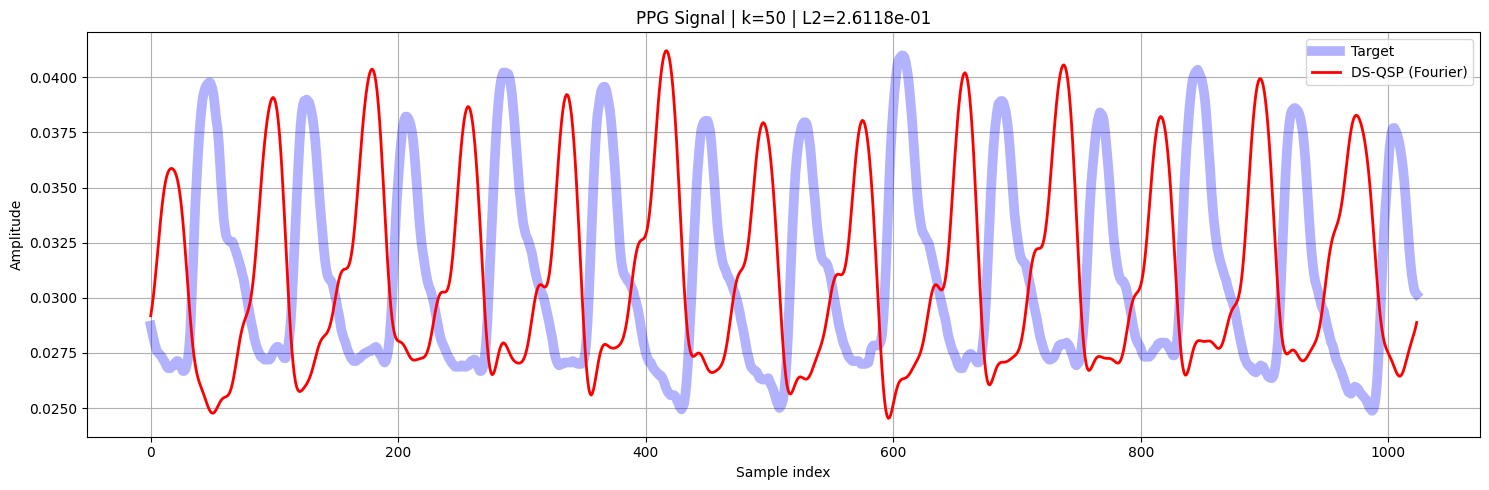

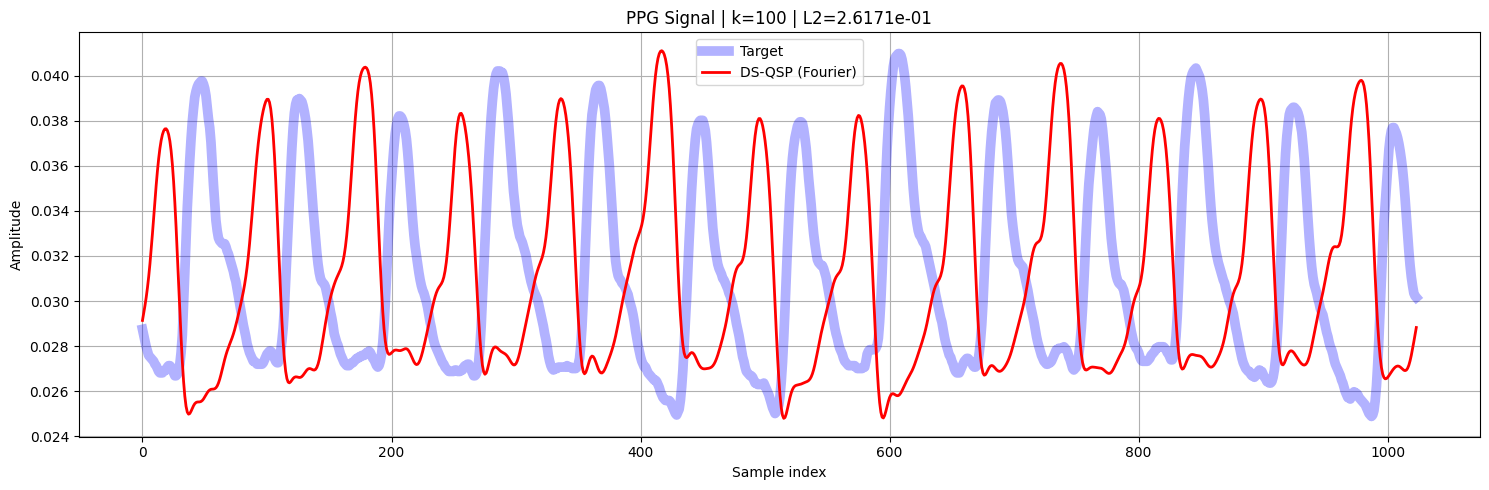

In [15]:
# ============================================================
# Plot reconstructed signals
# ============================================================

for k in [10, 20, 50, 100]:

    # Top-k Fourier coefficients
    Xk = topk(X, k)

    x_norm = Xk/np.linalg.norm(Xk)

    # Reconstruction
    x_rec = dft(x_norm).real

    # L2 error
    L2 = np.linalg.norm(target_f - x_rec)

    plt.figure(figsize=(15, 5))

    plt.plot(
        target_f,
        color="blue",
        lw=7,
        alpha=0.3,
        label="Target"
    )

    plt.plot(
        x_rec,
        color="red",
        lw=2,
        label="DS-QSP (Fourier)"
    )

    plt.title(
        f"PPG Signal | k={k} | L2={L2:.4e}"
    )

    plt.xlabel("Sample index")
    plt.ylabel("Amplitude")

    plt.grid(True)

    plt.legend()

    plt.tight_layout()

    plt.show()

k= 50 | TD=1.989681e-02 | Fidelity=0.9996041171


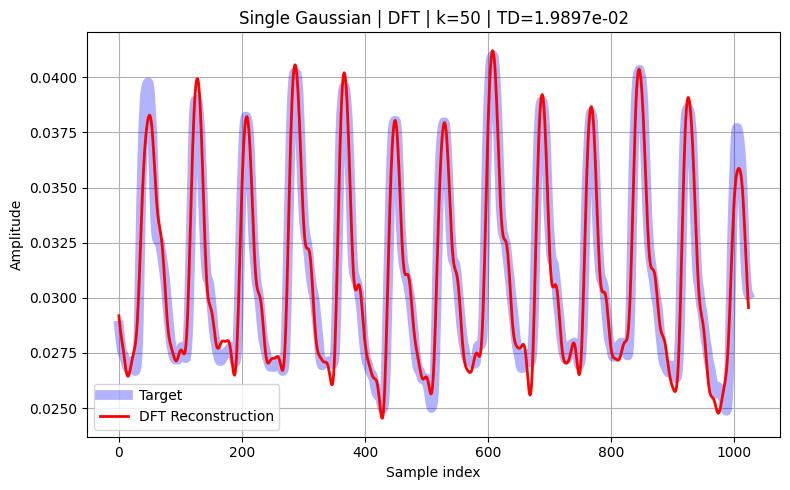

In [16]:
# ============================================================
# DFT compression of Single Gaussian
# ============================================================
# --------------------------------------------------------
# Forward transform
# --------------------------------------------------------
X = dft(signal[:1024])

# --------------------------------------------------------
# Top-k threshold
# --------------------------------------------------------
k=50
Xk = top_k_threshold(
        X,
        k
    )

# Remove negligible imaginary part
Xt = np.real_if_close(Xk)

x_norm = Xt/np.linalg.norm(Xt)
# --------------------------------------------------------
# Reconstruction
# --------------------------------------------------------
rec = idft(x_norm)


# --------------------------------------------------------
# Metrics
# --------------------------------------------------------

TD = trace_distance(target_f, rec)
F = state_fidelity(target_f, rec)

print(
      f"k={k:3d} | "
      f"TD={TD:.6e} | "
      f"Fidelity={F:.10f}"
    )

# --------------------------------------------------------
# Plot
# --------------------------------------------------------

plt.figure(figsize=(8,5))
plt.plot(
        target_f,
        color="blue",
        lw=7,
        alpha=0.30,
        label="Target"
    )

plt.plot(
      rec.real,
        color="red",
        lw=2,
        label="DFT Reconstruction"
    )

plt.title(
      f"Single Gaussian | DFT | "
      f"k={k} | TD={TD:.4e}"
    )

plt.xlabel("Sample index")
plt.ylabel("Amplitude")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
from qibo import Circuit, gates
from qibo.models import QFT
from qibo.models.encodings import sparse_encoder
from qibo.ui import plot_circuit

In [18]:
vec = x_norm

nz = np.flatnonzero(vec)             # Nonzero indices

y = [(format(i, f"0{n}b"), vec[i]) for i in nz]

# ------------------------------------------------
# Sparse encoder circuit
# ------------------------------------------------
circuit = sparse_encoder(y, method="farias")

# ------------------------------------------------
# inverse QFT
# ------------------------------------------------
#iqft = QFT(nqubits=nz).invert()

#circuit.add(iqft.on_qubits(*range(nz)))

#print(circuit.decompose().decompose().summary())
print(circuit.decompose().summary())

[Qibo 0.3.5|INFO|2026-07-12 19:44:00]: Using numpy backend on /CPU:0


IndexError: list index out of range

In [ ]:
nz

In [ ]:
x_norm

In [ ]:
y